In [1]:
from __future__ import annotations

import typing
import pathlib
import collections

import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as L
import neptune

import itertools
import einops
import gpytorch.constraints

from transformertf.data.transform import MinMaxScaler
from transformertf.nn import MLP, get_activation
from transformertf.main import _FilterCallback

from sa_preisach.utils import make_mesh_size_function, get_states, create_triangle_mesh
from sa_preisach.nn import BinaryParameter, GPyConstrainedParameter
from sa_preisach.models import BaseModule
from hysteresis.base import BaseHysteresis

torch.set_num_threads(12)

neptune.internal.operation_processors.async_operation_processor.logger.addFilter(
                _FilterCallback()
            )


In [2]:
CALIBRATION_FN_PATH = pathlib.Path("~/cernbox/hysteresis/calibration_fn/SPS_MB_I2B_CALIBRATION_FN_v7.csv").expanduser()

TRAIN_DF_PATH = pathlib.Path("~/cernbox/hysteresis/dipole/datasets/v6/MD20240904_all_drift_corrected_preprocessed.parquet").expanduser()
VAL_DF_PATH = pathlib.Path("~/cernbox/hysteresis/dipole/datasets/v6/extras/SPS-BTRAIN-20231102-093421---20231102-094342_phys+lhcfill_md1_precycle_preprocessed.parquet").expanduser()

In [3]:
calibration_fn = np.loadtxt(CALIBRATION_FN_PATH, delimiter=",", skiprows=1)
xs = calibration_fn[:, 0]
ys = calibration_fn[:, 1] * 0.95

train_df = pd.read_parquet(TRAIN_DF_PATH)
val_df = pd.read_parquet(VAL_DF_PATH)

In [4]:
DOWNSAMPLE = 50

train_df = train_df.iloc[::DOWNSAMPLE, :].reset_index(drop=True)
val_df = val_df.iloc[::DOWNSAMPLE, :].reset_index(drop=True)

In [5]:
train_h = train_df["I_ref_A"].to_numpy()
train_b = train_df["B_meas_T"].to_numpy() - np.interp(train_h, xs, ys)
# train_b = train_b + 2e-5 * train_h

val_h = val_df["I_ref_A"].to_numpy()
val_b = val_df["B_meas_T"].to_numpy() - np.interp(val_h, xs, ys)
# val_b = val_b + 2e-5 * val_h

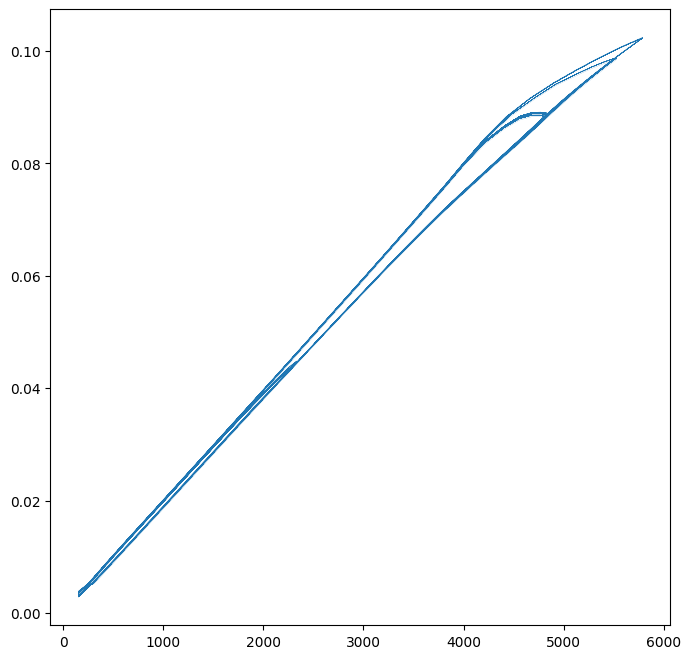

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.plot(train_h, train_b, label="train", linewidth=0.1)

In [7]:
h_scaler = MinMaxScaler(data_min_=100., data_max_=5800., frozen_=True)
h_scaler.fit(train_h)
h_train_norm = h_scaler.transform(train_h)
h_val_norm = h_scaler.transform(val_h)

b_scaler = MinMaxScaler(data_min_=-4e-3, data_max_=4e-3, frozen_=True)
b_scaler.fit(train_b)
b_train_norm = b_scaler.transform(train_b)
b_val_norm = b_scaler.transform(val_b)

The scaler is frozen and cannot be fitted.
The scaler is frozen and cannot be fitted.


In [8]:
class ResNetMLP(torch.nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_dim: int | tuple[int, ...], activation: str = "relu", dropout: float = 0.0) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.activation = activation
        self.dropout = dropout

        # if isinstance(hidden_dim, int):
        #     hidden_dim = (hidden_dim,) * 3

        layers = []
        in_features = input_dim
        for dim in hidden_dim:
            layers.append(torch.nn.Linear(in_features, dim))
            layers.append(torch.nn.BatchNorm1d(dim))
            layers.append(get_activation(activation))
            layers.append(torch.nn.Dropout(dropout))
            in_features = dim

        self.residual_layers = torch.nn.ModuleList(layers)
        self.output_layer = torch.nn.Linear(in_features, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for i in range(0, len(self.residual_layers), 4):
            residual = x if i != 0 else 0.0
            x = self.residual_layers[i](x)
            x = self.residual_layers[i + 1](x)
            x = self.residual_layers[i + 2](x)
            x = self.residual_layers[i + 3](x)
            # x += residual  # Add residual connection
            x = x + residual
        x = self.output_layer(x)
        return x
    

class DifferentiablePreisachModel(torch.nn.Module):
    def __init__(
        self,
        mesh_size: float,
        hidden_dim: int | tuple[int, ...] = (16, 16, 16),
        m_scale_bounds: tuple[float, float] = (0.0, 10.0),
        offset_bounds: tuple[float, float] = (-10.0, 10.0),
        h_slope_bounds: tuple[float, float] = (0.0, 10.0),
        normalized_density: bool = False,
        mesh_function: typing.Literal["constant", "default"] = "default",
    ) -> None:
        super().__init__()

        mesh = create_triangle_mesh(
            mesh_size,
            make_mesh_size_function(mesh_function),
        )

        # shift alpha and beta to be in the range (1e-2, 1 - 1e-2)
        mesh[:, 0] = mesh[:, 0] * 0.98 + 0.01
        mesh[:, 1] = mesh[:, 1] * 0.98 + 0.01

        self.alpha = GPyConstrainedParameter(
            torch.tensor(mesh[:, 1], requires_grad=True).float(),
            constraint=gpytorch.constraints.Interval(0.0, 1.0),
        )
        self.beta = GPyConstrainedParameter(
            torch.tensor(mesh[:, 0], requires_grad=True).float(),
            constraint=gpytorch.constraints.Interval(0.0, 1.0),
        )
        n_mesh_points = mesh.shape[0]

        self.density = ResNetMLP(
            input_dim=2,
            output_dim=1,
            hidden_dim=hidden_dim,
            activation="relu",
            dropout=0.1,
        )
        self.density_activation = torch.nn.Sigmoid() if normalized_density else torch.nn.LeakyReLU()

        self.m_scale = GPyConstrainedParameter(
            torch.tensor(1.0),
            constraint=gpytorch.constraints.Interval(*m_scale_bounds),
        )
        self.m_offset = GPyConstrainedParameter(
            torch.tensor(0.0),
            constraint=gpytorch.constraints.Interval(*offset_bounds),
        )
        self.h_scale = GPyConstrainedParameter(
            torch.tensor(1.0),
            constraint=gpytorch.constraints.Interval(*h_slope_bounds),
        )

        initial_state = torch.zeros((1, n_mesh_points), dtype=torch.float32)
        torch.nn.init.xavier_uniform_(initial_state.data)
        initial_state = initial_state.squeeze(0)  # hack to use torch.nn.init

        self.initial_state = BinaryParameter(
            initial_state,
        )

    def forward(
            self,
            x: torch.Tensor,
            y0: torch.Tensor | float = 0.0,
            *,
            temp: float = 1e-3,
            state: torch.Tensor | None = None,
        ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if state is not None:
            states = state
        else:
            states = get_states(
                x,
                self.alpha.value,
                self.beta.value,
                temp=temp,
                current_state=self.initial_state.value,
                current_field=y0,
                dtype=torch.float32,
                training=self.training,
            )

        density = self.density(self.mesh)
        density = self.density_activation(density)
        density = einops.rearrange(density, "n 1 -> 1 n")

        m = torch.sum(density * states, dim=-1) / torch.sum(density, dim=-1)

        return self.m_scale.value * m + self.m_offset.value + self.h_scale.value * x, density, states

    @property
    def mesh(self) -> torch.Tensor:
        return torch.cat([
            self.alpha.value.unsqueeze(-1),
            self.beta.value.unsqueeze(-1),
        ], dim=1)


class DifferentiablePreisach(L.LightningModule):
    def __init__(
        self,
        mesh_size: float,
        *,
        hidden_dim: int | tuple[int, ...] = (16, 16, 16),
        temp: float = 1e-3,
        lr: float = 1e-2,
        lr_scale: float = 1e-3,
        lr_grid: float = 1e-2,
        lr_sa: float = 1e-2,
        gradient_clip: float = 1.0,
        m_scale_bounds: tuple[float, float] = (0.0, 10.0),
        offset_bounds: tuple[float, float] = (-10.0, 10.0),
        h_slope_bounds: tuple[float, float] = (0.0, 10.0),
        dist_threshold: float = 1e-3,
        normalized_density: bool = False,
        mesh_function: typing.Literal["constant", "default"] = "default",
        compile_model: bool = True,
        phase1: int = 100,
        phase2: int = 100,
        phase3: int = 100,
        phase4: int = 100,
        phase5: int = 100,
        phase6: int = 100,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()

        self.model = DifferentiablePreisachModel(
            mesh_size=mesh_size,
            hidden_dim=hidden_dim,
            m_scale_bounds=m_scale_bounds,
            offset_bounds=offset_bounds,
            h_slope_bounds=h_slope_bounds,
            normalized_density=normalized_density,
            mesh_function=mesh_function,
        )

        self.loss_weights = torch.nn.Parameter(
            torch.tensor([1.0, 1.0, 1.0, 1.0]),
            requires_grad=True,
        )

        self.validation_outputs = list()
        self.automatic_optimization = False

        self.current_state: torch.Tensor | None = None
        self.states: torch.Tensor | None = None

        self._cum_phase = torch.cumsum(
            torch.tensor([0, phase1, phase2, phase3, phase4, phase5]),
            dim=0,
        ) * 2

    def on_fit_start(self) -> None:
        if self.hparams["compile_model"]:
            self.model = torch.compile(self.model)

        return super().on_fit_start()

    def on_validation_epoch_start(self):
        self.validation_outputs = list()
        return super().on_validation_epoch_start()

    def forward(self, x: torch.Tensor, y0: torch.Tensor | float = 0.0, *, temp: float = 1e-3, states: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.model(x, y0, temp=temp, state=states)

    def common_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int, states: torch.Tensor | None = None) -> dict[str, torch.Tensor]:
        x, y = batch
        x = x.squeeze(0)
        y = y.squeeze(0)
        y_hat, density, states = self(x, y0=y[0], temp=self.hparams["temp"], states=states)
        loss1 = torch.nn.functional.mse_loss(y_hat, y)
        loss2 = self.parameter_constraint_loss()
        loss3 = overlap_penalty_loss(self.model.mesh, min_dist=1e-6, constant=self.hparams["dist_threshold"] ** 2)
        # loss4 = torch.abs(y_hat[0] - y[0])

        loss = sum(self.loss_weights[i] * loss for i, loss in enumerate([loss1, loss2, loss3]))

        return {
            "loss": loss,
            "loss_weights": self.loss_weights.detach().clone(),
            "loss1": loss1,
            "loss2": loss2,
            "loss3": loss3,
            # "loss4": loss4,
            "y_hat": y_hat,
            "y": y,
            "x": x,
            "density": density.detach().clone(),
            "states": states.detach().clone(),
        }

    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> dict[str, torch.Tensor]:
        out = self.common_step(batch, batch_idx, states=self.states if (self.phase5) else None)
        loss = out["loss"]

        self.states = out["states"]

        optimizer1, optimizer2 = self.optimizers()
        optimizer1.zero_grad()
        optimizer2.zero_grad()

        self.manual_backward(loss)

        self.clip_gradients(
            optimizer1,
            gradient_clip_val=self.hparams["gradient_clip"],
        )
        self.clip_gradients(
            optimizer2,
            gradient_clip_val=self.hparams["gradient_clip"],
        )

        optimizer1.step()

        self.lr_scheduler_step(self.lr_schedulers(), metric=None)

        self.negate_gradients()
        optimizer2.step()

        for tag, key in {
            "train/loss": "loss",
            "train/loss_mse": "loss1",
            "train/loss_alpha_geq_beta": "loss2",
            "train/loss_overlap": "loss3",
            # "train/loss_i0": "loss4",
        }.items():
            self.log(tag, out[key], prog_bar=True, on_step=True, on_epoch=False)

        for tag, i in {
            "train/loss_weight_mse": 0,
            "train/loss_weight_alpha_geq_beta": 1,
            "train/loss_weight_overlap": 2,
            "train/loss_weight_i0": 3,
        }.items():
            self.log(tag, self.loss_weights[i], prog_bar=True, on_step=True, on_epoch=False)

        return out

    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> dict[str, torch.Tensor]:
        with torch.no_grad():
            out = self.common_step(batch, batch_idx)

        for tag, key in {
            "validation/loss": "loss",
            "validation/loss_mse": "loss1",
        }.items():
            self.log(tag, out[key], prog_bar=True, on_step=False, on_epoch=True)

        self.validation_outputs.append(out)
        return out

    def parameter_constraint_loss(self) -> torch.Tensor:
        return torch.sum(torch.nn.functional.relu(self.model.beta.value - self.model.alpha.value))

    def negate_gradients(self) -> None:
        for param in self.parameters():
            if param.grad is not None:
                param.grad = -param.grad

    def configure_optimizers(self) -> tuple[list[torch.optim.Optimizer], list[torch.optim.lr_scheduler.LRScheduler]]:
        optimizer1 = torch.optim.AdamW([{
          "params": self.model.density.parameters(),
            "lr": self.hparams["lr"],
            "weight_decay": 1e-4,  # only weight decay for the MLP
        },
        {
            "params": self.model.initial_state.parameters(),
            "lr": self.hparams["lr"],
            "weight_decay": 0.0, 
        },
        {
            "params": itertools.chain(self.model.alpha.parameters(), self.model.beta.parameters()),
            "lr": self.hparams["lr_grid"],
            "weight_decay": 0.0,
        },
        {
            "params": itertools.chain(self.model.m_scale.parameters(), self.model.m_offset.parameters(), self.model.h_scale.parameters()),
            "lr": self.hparams["lr_scale"],
            "weight_decay": 0.0,
        }
        ],
        )
        optimizer2 = torch.optim.SGD(
            [self.loss_weights],
            lr=self.hparams["lr_sa"]
        )
        scheduler1 = torch.optim.lr_scheduler.StepLR(optimizer1, step_size=200, gamma=0.95)
        return [optimizer1, optimizer2], [scheduler1]
    
    def state_dict(
        self,
        *args: typing.Any,
        destination: dict[str, torch.Tensor] | None = None,
        prefix: str = "",
        keep_vars: bool = False,
    ) -> dict[str, torch.Tensor]:
        state_dict = super().state_dict(
            *args, destination=destination, prefix=prefix, keep_vars=keep_vars
        )

        # hack to save the original model state dict and not the compiled one
        # this assumes that internally the model is stored in the `model` attribute
        # and that the model is not compiled when the LightningModule is instantiated

        # keys are xxx._orig_mod.xxx, remove _orig_mod
        if self.hparams.get("compile_model"):
            odict = collections.OrderedDict()
            for k in list(state_dict.keys()):
                if "_orig_mod" in k:
                    new_key = k.replace("_orig_mod.", "")
                    odict[new_key] = state_dict[k]
                else:
                    odict[k] = state_dict[k]

            state_dict = odict

        return state_dict
    
    @property
    def phase1(self) -> bool:
        """
        Phase 1: Train the model with only m_scale, m_offset, h_scale and initial_state unfrozen.
        """
        return self.global_step < self._cum_phase[1]
    
    @property
    def phase2(self) -> bool:
        """
        Phase 2: Freeze m_scale, m_offset, h_scale and initial_state, train only the density.
        """ 
        return self._cum_phase[1] <= self.global_step < self._cum_phase[2]
    
    @property
    def phase3(self) -> bool:
        """
        Phase 3: Freeze density, finetune m_scale, m_offset, h_scale and initial_state.
        """
        return self._cum_phase[2] <= self.global_step < self._cum_phase[3]
    
    @property
    def phase4(self) -> bool:
        """
        Phase 4: Freeze everything instead of the mesh.
        """ 
        return self._cum_phase[3] <= self.global_step < self._cum_phase[4]
    
    @property
    def phase5(self) -> bool:
        """
        Unlock mesh and train the model with m_scale, m_offset, h_scale and initial_state unfrozen.
        """
        return self._cum_phase[4] <= self.global_step < self._cum_phase[5]
    
    @property
    def phase6(self) -> bool:
        """
        Phase 6: Train the model with all parameters unfrozen.
        """
        return self.global_step >= self._cum_phase[5]

    def on_train_epoch_start(self) -> None:
        if self.global_step == 0:
            # start with scales and initial state
            set_requires_grad(self.model.density, flag=False)
            self.model.density.eval()
            set_requires_grad(self.model.alpha, flag=False)
            set_requires_grad(self.model.beta, flag=False)
            set_requires_grad(self.loss_weights, flag=False)
            # set_requires_grad(self.model.initial_state, flag=False)

        elif self.global_step == self._cum_phase[1]:
            # freeze scales and initial state, train mesh
            set_requires_grad(self.model.alpha, flag=True)
            set_requires_grad(self.model.beta, flag=True)
            set_requires_grad(self.model.m_scale, flag=False)
            set_requires_grad(self.model.m_offset, flag=False)
            set_requires_grad(self.model.h_scale, flag=False)
            set_requires_grad(self.model.initial_state, flag=False)
            set_requires_grad(self.loss_weights, flag=True)

        elif self.global_step == self._cum_phase[2]:
            # finetune scales and initial state
            set_requires_grad(self.model.m_scale, flag=True)
            set_requires_grad(self.model.m_offset, flag=True)
            set_requires_grad(self.model.h_scale, flag=True)
            set_requires_grad(self.model.initial_state, flag=True)

        elif self.global_step == self._cum_phase[3]:
            # set_requires_grad(self.model.density, flag=True)
            # self.model.density.train()
            set_requires_grad(self.model.m_scale, flag=False)
            set_requires_grad(self.model.m_offset, flag=False)
            set_requires_grad(self.model.h_scale, flag=False)
            set_requires_grad(self.model.initial_state, flag=False)
            set_requires_grad(self.model.alpha, flag=True)
            set_requires_grad(self.model.beta, flag=True)

        elif self.global_step == self._cum_phase[4]:
            # enable density only when everything else is fitted
            set_requires_grad(self.model.density, flag=True)
            self.model.density.train()
            # set_requires_grad(self.model.initial_state, flag=True)
            set_requires_grad(self.model.alpha, flag=False)
            set_requires_grad(self.model.beta, flag=False)

            # enable scales
            set_requires_grad(self.model.m_scale, flag=True)
            set_requires_grad(self.model.m_offset, flag=True)
            set_requires_grad(self.model.h_scale, flag=True)

        elif self.global_step == self._cum_phase[5]:
            # fit density and mesh
            set_requires_grad(self.model.density, flag=True)
            self.model.density.train()
            # set_requires_grad(self.model.m_scale, flag=True)
            # set_requires_grad(self.model.m_offset, flag=True)
            # set_requires_grad(self.model.h_scale, flag=True)
            # set_requires_grad(self.model.initial_state, flag=True)
            set_requires_grad(self.model.alpha, flag=True)
            set_requires_grad(self.model.beta, flag=True)

        return super().on_train_epoch_start()


def set_requires_grad(param_or_module: torch.nn.Module | torch.nn.Parameter, *, flag: bool) -> None:
    if isinstance(param_or_module, torch.nn.Module):
        for p in param_or_module.parameters():
            p.requires_grad = flag
    else:
        param_or_module.requires_grad = flag
               

def overlap_penalty_loss(pairs: torch.Tensor, min_dist: float = 1e-6, constant: float = 1e-6) -> torch.Tensor:
    """
    Penalize overlapping (x, y) pairs in a tensor of shape (N, 2) using 1/distance^2.

    Overlapping should only be a problem when distance is < 1e-3
    Args:
        pairs: Tensor of shape (N, 2)
        min_dist: Minimum allowed distance between pairs
        constant: Multiplication constant for the penalty
    Returns:
        penalty: Scalar tensor with the overlap penalty
    """
    # Compute pairwise distances (N, N)
    diff = pairs.unsqueeze(1) - pairs.unsqueeze(0)  # (N, N, 2)
    dists = torch.norm(diff, dim=-1)  # (N, N)
    # Ignore self-distances by setting diagonal to a large value
    dists = dists + torch.eye(pairs.shape[0], device=pairs.device) * 1e6
    # Penalize distances below min_dist using 1/distance^2
    penalty = torch.mean(constant / torch.pow(torch.clamp(dists, min=min_dist), 2))
    return penalty

In [9]:
# count parameters
model = DifferentiablePreisach(
    mesh_size=0.1,
    temp=1e-3,
)

n_params = sum(p.numel() for p in model.parameters())
n_params

22945

In [10]:
model.model.alpha.value, model.model.beta.value

(tensor([0.0100, 0.9900, 0.9900,  ..., 0.9708, 0.7148, 0.0410],
        grad_fn=<AddBackward0>),
 tensor([0.0100, 0.9900, 0.0100,  ..., 0.9610, 0.5805, 0.0174],
        grad_fn=<AddBackward0>))

In [11]:
y, density, states = model(h_train_norm[:1000])
y = y.detach().numpy()

In [12]:
class Dataset(torch.utils.data.Dataset):
    def __init__(
        self,
        h: torch.Tensor,
        b: torch.Tensor,
    ) -> None:
        super().__init__()
        self.h = h
        self.b = b

    def __len__(self) -> int:
        return 1

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.h, self.b
    
    
train_dataset = Dataset(
    h_train_norm,
    b_train_norm,
)
val_dataset = Dataset(
    h_val_norm,
    b_val_norm,
)


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [13]:
class PlotHysteresisCallback(L.pytorch.callbacks.Callback):
    def __init__(self, validate_every_n_epochs: int = 1) -> None:
        super().__init__()
        self.validate_every_n_epochs = validate_every_n_epochs

    def on_validation_epoch_end(self, trainer: L.Trainer, pl_module: DifferentiablePreisach) -> None:
        if not trainer.is_global_zero:
            return
        
        if trainer.current_epoch % self.validate_every_n_epochs != 0:
            return
        
        # get the last validation output
        last_output = pl_module.validation_outputs[-1]
        x = last_output["x"]
        y = last_output["y"]
        y_hat = last_output["y_hat"]
        x = x.squeeze(0)
        y = y.squeeze(0)
        y_hat = y_hat.squeeze(0)

        x = h_scaler.inverse_transform(x)
        y = b_scaler.inverse_transform(y)
        y_hat = b_scaler.inverse_transform(y_hat)

        fig_hysteresis = plot_hysteresis(x, y, y_hat)

        self._log_figure(trainer, fig_hysteresis, tag="validation/hysteresis")
        plt.close(fig_hysteresis)

        # plot the hysteron density
        density = last_output["density"]
        density = density.squeeze(0)

        alpha = pl_module.model.alpha.value
        beta = pl_module.model.beta.value

        fig_density = plot_hysteron_density(
            alpha,
            beta,
            density,
        )

        self._log_figure(trainer, fig_density, tag="validation/hysteron_density")
        plt.close(fig_density)

        # plot the hysteron scatter
        fig_scatter = plot_hysteron_scatter(
            alpha,
            beta,
        )
        self._log_figure(trainer, fig_scatter, tag="validation/hysteron_scatter")
        plt.close(fig_scatter)
        
    def _log_figure(self, trainer: L.Trainer, fig: matplotlib.figure.Figure, tag: str) -> None:
        if trainer.logger is None:
            return
        if isinstance(trainer.logger, L.pytorch.loggers.neptune.NeptuneLogger):
            trainer.logger.experiment[tag].append(fig)
        elif isinstance(trainer.logger, L.pytorch.loggers.TensorBoardLogger):
            trainer.logger.experiment.add_figure(tag, fig, global_step=trainer.global_step)
        else:
            msg = "Logger not supported"
            raise NotImplementedError(msg)
        

def plot_hysteresis(
    x: torch.Tensor,
    y: torch.Tensor,
    y_hat: torch.Tensor,
) -> matplotlib.figure.Figure:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={"height_ratios": [2, 1]})

    x = x.detach().cpu().numpy()
    y = y.detach().cpu().numpy()
    y_hat = y_hat.detach().cpu().numpy()

    ax1.plot(x, y, label="data")
    ax1.plot(x, y_hat, label="model")

    ax1.set_xlabel("I [A]")
    ax1.set_ylabel("B [T]")

    ax1.legend()
    ax1.grid()
    ax1.set_title("Hysteresis")

    ax2.plot(x, y - y_hat, label="error")
    ax2.set_xlabel("I [A]")
    ax2.set_ylabel("B [T]")

    return fig

def plot_hysteron_density(
    alpha: torch.Tensor,
    beta: torch.Tensor, 
    density: torch.Tensor,
) -> matplotlib.figure.Figure:
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))

    density = density.detach().cpu().numpy()
    alpha = alpha.detach().cpu().numpy()
    beta = beta.detach().cpu().numpy()

    c = ax.tripcolor(
        beta,
        alpha,
        density,
        # shading="gouraud",
        cmap="viridis",
        # vmin=0.0,
        # vmax=1.0,
    )
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("$\\beta$")
    ax.set_ylabel("$\\alpha$")

    ax.set_title("Hysteron density")

    return fig

def plot_hysteron_scatter(
    alpha: torch.Tensor,
    beta: torch.Tensor, 
) -> matplotlib.figure.Figure:
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))

    alpha = alpha.detach().cpu().numpy()
    beta = beta.detach().cpu().numpy()

    ax.scatter(
        beta,
        alpha,
        s=1,
        c="black",
        alpha=0.5,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="black",
        label="$\\alpha = \\beta$",
        linewidth=0.5,
    )
    ax.plot(
        [0, 0],
        [0, 1],
        color="black",
        label="$\\beta = 0$",
        linewidth=0.5,
    )
    ax.plot(
        [0, 1],
        [1, 1],
        color="black",
        label="$\\alpha = 1$",
        linewidth=0.5,
    )

    ax.set_xlabel("$\\beta$")
    ax.set_ylabel("$\\alpha$")
    ax.set_title("Hysteron scatter")

    return fig

In [25]:
API_KEY = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI4NDIwNDFiOC04YzQ5LTQ5YTktYmY2OS03YTNhMWRmZTc0NWYifQ=="

trainer = L.Trainer(
    accelerator="cpu",
    max_epochs=4000,
    devices=1,
    callbacks=[
        PlotHysteresisCallback(validate_every_n_epochs=50),
        L.pytorch.callbacks.LearningRateMonitor(logging_interval="epoch"),
        L.pytorch.callbacks.RichModelSummary(max_depth=2),
        L.pytorch.callbacks.ModelCheckpoint(
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="epoch={epoch}-loss={validation/loss:.2f}",
            auto_insert_metric_name=False,
        )
    ],
    log_every_n_steps=1,
    logger=L.pytorch.loggers.NeptuneLogger(
        api_key=API_KEY,
        project="hysteresis/Preisach-NN",
        prefix="",
        proxies={"http": "http://cs-513-ml001:8080", "https": "http://cs-513-ml001:8080"}
    )
)

Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [26]:
model = DifferentiablePreisach(
    mesh_size=0.006,
    hidden_dim=(32, 32, 32),
    temp=1e-3,
    lr=1e-3,
    lr_scale=1e-2,
    lr_grid=1e-2,
    lr_sa=1e-1,
    gradient_clip=1.0,
    dist_threshold=1e-3,
    normalized_density=True,
    mesh_function="constant",
    compile_model=True,
    phase1=220,
    phase2=600,
    phase3=600,
    phase4=400,
    phase5=600,
    phase6=500,
)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

Number of parameters: 51646


In [ ]:
trainer.fit(
    model,
    train_loader,
    val_loader,
)

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/hysteresis/Preisach-NN/e/PREISNN-56


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃   ┃ Name                     ┃ Type                        ┃ Params ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ 0 │ model                    │ DifferentiablePreisachModel │ 51.6 K │
│ 1 │ model.alpha              │ GPyConstrainedParameter     │ 16.4 K │
│ 2 │ model.beta               │ GPyConstrainedParameter     │ 16.4 K │
│ 3 │ model.density            │ ResNetMLP                   │  2.4 K │
│ 4 │ model.density_activation │ Sigmoid                     │      0 │
│ 5 │ model.m_scale            │ GPyConstrainedParameter     │      1 │
│ 6 │ model.m_offset           │ GPyConstrainedParameter     │      1 │
│ 7 │ model.h_scale            │ GPyConstrainedParameter     │      1 │
│ 8 │ model.initial_state      │ BinaryParameter             │ 16.4 K │
└───┴──────────────────────────┴─────────────────────────────┴────────┘

Trainable params: 51.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.6 K                                                                                               
Total estimated model params size (MB): 0

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Training: |                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

In [ ]:
model.model.m_scale.value, model.model.m_offset.value, model.model.h_scale.value

(tensor(5.8358), tensor(3.2047), tensor(5.4629))

[neptune] [error  ] Error occurred during asynchronous operation processing: X-coordinates (step) must be strictly increasing for series attribute: epoch. Invalid point: 608.0


In [19]:
model.model.alpha.data, model.model.beta.data

(Parameter containing:
 tensor([-4.5951,  4.5951,  4.5951,  ...,  3.5023,  0.9189, -3.1531]),
 Parameter containing:
 tensor([-4.5951,  4.5951, -4.5951,  ...,  3.2045,  0.3250, -4.0356]))

In [20]:
value

NameError: name 'value' is not defined

In [ ]:
b_scaler.data_max, b_scaler.data_min

[neptune] [error  ] Error occurred during asynchronous operation processing: X-coordinates (step) must be strictly increasing for series attribute: epoch. Invalid point: 43.0


In [ ]:
_, f = initialize_state(
    n_mesh_points=model.alpha.shape[0]
)

In [ ]:
assert not train_dataset[0][0][0] > f